In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
from torchmetrics.classification import MulticlassF1Score

In [3]:
seed_everything(42)

42

In [3]:
seed_everything(42)


transform = transforms.Compose([
    transforms.Resize((224, 224)),  # AlexNet принимает вход размером 224x224
    transforms.ToTensor(),
   # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


100%|██████████| 169M/169M [00:02<00:00, 65.4MB/s] 


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


Классическая архитектура АлексНет

In [4]:
class AlexNet(LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2), nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, 100)  
        )
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        acc = (preds.argmax(dim=1) == y).float().mean()
        self.log("test_acc", acc, prog_bar=True)
        return acc

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer


ModelCheckpoint автоматически сохраняет веса модели в "лучший" момент на валидации, при сбое можно "загрузиться" с чекпоинта и продолжить обучение
EarlyStopping. Eсли модель перестает улучшать свои показатели на валидационной выборке, EarlyStopping автоматически останавливает обучение, чтобы избежать переобучения.

In [5]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", dirpath="checkpoints/")
early_stopping_callback = EarlyStopping(monitor="val_loss", patience=5, mode="min")

trainer = Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

model = AlexNet(lr=1e-3)
trainer.fit(model, train_loader, val_loader)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [6]:
best_model = AlexNet.load_from_checkpoint(checkpoint_callback.best_model_path)
trainer.test(best_model, test_loader)


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.26080000400543213    │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.26080000400543213}]

Результаты с растянутыми 32х32 изображениями до 224х224 (для алекснета) заставляют задуматься... 1% точность, в прочем возможно стоило использовать другую метрику, но и так ясно, что она будет около нулевой. 
Далее попробую адаптировать слои к входному изображению CIFAR100 и добавлю аугментацию

In [5]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
  #  transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


dataset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


100%|██████████| 169M/169M [00:02<00:00, 76.2MB/s] 


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

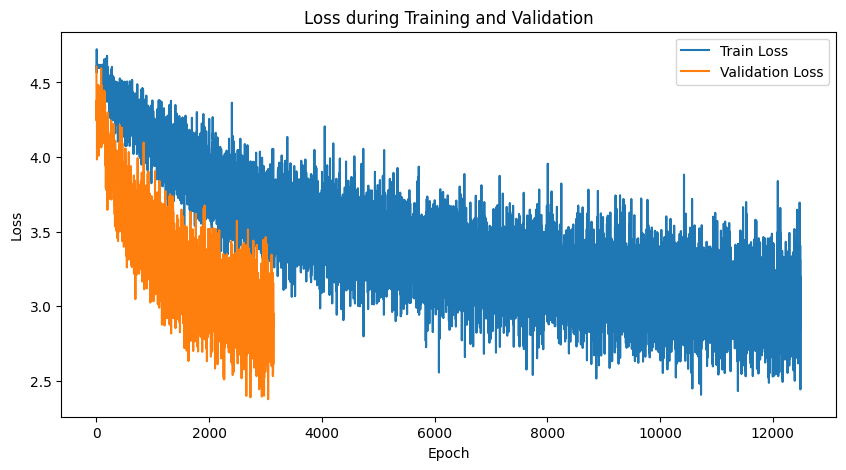

Testing: |          | 0/? [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.62      0.50      0.55       100
           1       0.33      0.37      0.35       100
           2       0.16      0.15      0.16       100
           3       0.13      0.09      0.11       100
           4       0.00      0.00      0.00       100
           5       0.14      0.42      0.21       100
           6       0.30      0.23      0.26       100
           7       0.28      0.23      0.25       100
           8       0.32      0.25      0.28       100
           9       0.29      0.52      0.38       100
          10       0.24      0.16      0.19       100
          11       0.20      0.10      0.13       100
          12       0.40      0.31      0.35       100
          13       0.32      0.19      0.24       100
          14       0.15      0.10      0.12       100
          15       0.17      0.16      0.16       100
          16       0.19      0.29      0.23       100
          17       0.41    

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.28139999508857727    │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.28139999508857727}]

In [6]:
class AlexNetAdapted(LightningModule):
    def __init__(self, lr=1e-3, num_classes=100):
        super().__init__()
        self.save_hyperparameters()
        self.num_classes = num_classes
        self.test_outputs = []
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2), nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flattened_size = 256 * 3 * 3
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.train_losses = []
        self.val_losses = []
        self.train_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.val_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.train_losses.append(loss.item())
        f1 = self.train_f1(preds, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_f1", f1, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.val_losses.append(loss.item())
        f1 = self.val_f1(preds, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_f1", f1, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        preds_classes = preds.argmax(dim=1)
        self.test_outputs.append({"y_true": y.cpu(), "y_pred": preds_classes.cpu()})
        acc = (preds_classes == y).float().mean()
        self.log("test_acc", acc, prog_bar=True)
        return acc

    def on_test_epoch_end(self):
        y_true = torch.cat([out["y_true"] for out in self.test_outputs])
        y_pred = torch.cat([out["y_pred"] for out in self.test_outputs])
        self.test_outputs = []
        print(classification_report(y_true.numpy(), y_pred.numpy(), target_names=[str(i) for i in range(self.num_classes)]))

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

    def on_train_end(self):
        self.plot_losses()

    def plot_losses(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label="Train Loss")
        plt.plot(self.val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Loss during Training and Validation")
        plt.show()


model = AlexNetAdapted(lr=1e-3, num_classes=100)

checkpoint_callback = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", dirpath="checkpoints/")
early_stopping_callback = EarlyStopping(monitor="val_loss", patience=5, mode="min")

trainer = Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

trainer.fit(model, train_loader, val_loader)

trainer.test(model, test_loader)


Намного лучше чем классическая версия AlexNet, но все равно слабовато( График функции потерь очень нестабильный, но общая тенденция к уменьшению функции потерь, сейчас задумался, что может стоило взять 10 видов изображений, а не 100....